In [1]:
import xarray as xr
import numpy as np 
import scipy
import os
import xeofs
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
from sklearn.decomposition import PCA

import pandas as pd
import string
from src import config_cesm
from src.utils import util_cesm
from src.models.diagnostics import roll_metric
from src.utils.bootstrap import benjamini_hochberg
from src.experiment_configs.exp1_inputs import CONFIGS

reference_grid = util_cesm.generate_sps_grid()
CNAMES = ["input2", "input3a", "input3b", "input3c", "input3d"]

prc_data_dir = Path(config_cesm.PROCESSED_DATA_DIRECTORY)

def add_hatching(ax, significance_mask, x_edges, y_edges, hatch='///', edgecolor='k'):
    Ny, Nx = significance_mask.shape

    for i in range(Ny):
        for j in range(Nx):
            if significance_mask[i, j]:
                rect = mpatches.Rectangle(
                    (x_edges[j], y_edges[i]),
                    x_edges[j+1] - x_edges[j],
                    y_edges[i+1] - y_edges[i],
                    hatch=hatch,
                    fill=False,
                    edgecolor=edgecolor,
                    linewidth=0
                )
                ax.add_patch(rect)

def plot_markers(ax, exceeds_baseline, x_centers, y_centers, marker='.k'):
    for i in range(6):
        for j in range(12):
            if not exceeds_baseline[i,j]:
                ax.plot(x_centers[j], y_centers[i], marker, markersize=4) 

def add_subplot_labels(axs):
    panel_labels = list(string.ascii_lowercase)
    for i, ax in enumerate(axs):
        if ax.get_visible():
            ax.annotate(f"{panel_labels[i]})", xy=(0, 1), xycoords="axes fraction", xytext=(-0.1, 1.03), 
                textcoords="axes fraction", ha="left", va="bottom", fontsize=11, fontweight="bold")



In [2]:
acc = {}
acc_agg = {}
rmse = {}
rmse_agg = {}
significance_ds = {}
significance_ds_rmse = {}

input_configs_extended = CNAMES + ["input3e", "input3f", "input3g", "input3h_to500", "input4a", "input4b", "input5", "input5_noSIC"]

for cname in input_configs_extended:
    acc_agg[cname] = xr.open_dataset(
        os.path.join(config_cesm.PREDICTIONS_DIRECTORY, f"exp1_{cname}", "diagnostics/acc_agg.nc")
    )["acc"]
    rmse_agg[cname] = xr.open_dataset(
        os.path.join(config_cesm.PREDICTIONS_DIRECTORY, f"exp1_{cname}", "diagnostics/rmse_agg.nc")
    )["rmse"]
    acc[cname] = xr.open_dataset(
        os.path.join(config_cesm.PREDICTIONS_DIRECTORY, f"exp1_{cname}", "diagnostics/acc.nc")
    )["acc"]
    rmse[cname] = xr.open_dataset(
        os.path.join(config_cesm.PREDICTIONS_DIRECTORY, f"exp1_{cname}", "diagnostics/rmse.nc")
    )["rmse"]


persistence_acc = xr.open_dataset(
    os.path.join(config_cesm.PREDICTIONS_DIRECTORY, "exp1_input2", "diagnostics/acc_agg_persist.nc")
)["acc"].squeeze()
persistence_rmse = xr.open_dataset(
    os.path.join(config_cesm.PREDICTIONS_DIRECTORY, "exp1_input2", "diagnostics/rmse_agg_persist.nc")
)["rmse"].squeeze()
climatology_rmse = xr.open_dataset(
    os.path.join(config_cesm.PREDICTIONS_DIRECTORY, "exp1_input2", "diagnostics/rmse_agg_climatology.nc")
)["rmse"].squeeze()

for cname in input_configs_extended:
    if cname == "input2":
        continue

    significance_ds[cname] = xr.open_dataset(
        os.path.join(config_cesm.ANALYSIS_RESULTS_DIRECTORY, f"confidence_intervals/exp1_input2_exp1_{cname}_acc.nc")
    )

    significance_ds_rmse[cname] = xr.open_dataset(
        os.path.join(config_cesm.ANALYSIS_RESULTS_DIRECTORY, f"confidence_intervals/exp1_input2_exp1_{cname}_rmse.nc")
    )

# Treat all model-by-month-by-lead comparisons shown for one metric as
# a single Benjamini-Hochberg false-discovery-rate family.
FDR_CONFIGS = [
    "input3a", "input3f", "input3h_to500", "input3b", "input3c",
    "input3e", "input3d", "input4a", "input4b", "input3g", "input5",
]

def global_fdr_q_values(results, configs):
    p_values = xr.concat(
        [results[cname].p_value.expand_dims(config=[cname]) for cname in configs],
        dim="config",
    )
    return p_values.copy(data=benjamini_hochberg(p_values.values))

acc_q_values = global_fdr_q_values(significance_ds, FDR_CONFIGS)
rmse_q_values = global_fdr_q_values(significance_ds_rmse, FDR_CONFIGS)


<>:55: SyntaxWarning: invalid escape sequence '\D'
<>:55: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_27269/1171284971.py:55: SyntaxWarning: invalid escape sequence '\D'
  ax.set_title(f"$\Delta$ ACC: add {input_configs_to_plot[input_config]}",


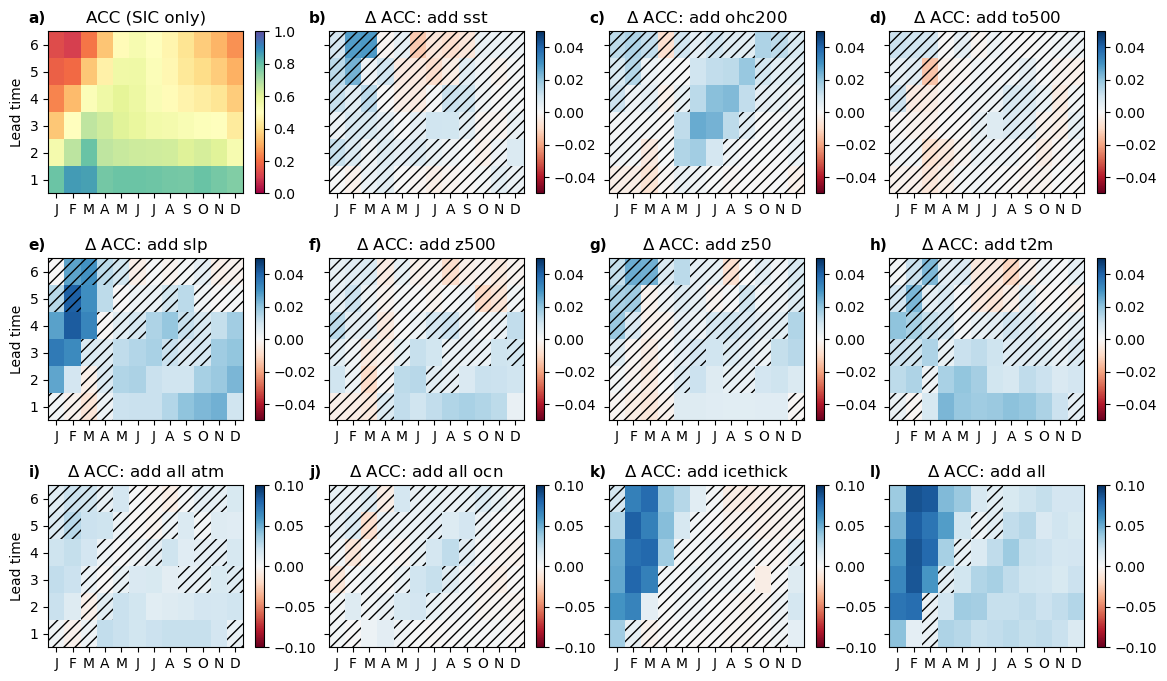

In [12]:
FALSE_DISCOVERY_RATE = 0.05

fig, axs = plt.subplots(nrows=3, ncols=4, figsize=(14, 8), sharey=True)

x = np.arange(13)
y = np.arange(7)
x_centers = (x[:-1] + x[1:]) / 2
y_centers = (y[:-1] + y[1:]) / 2

acc_input2 = acc_agg["input2"].mean("nn_member_id")

input_configs_to_plot = {
    "input3a": "sst",
    "input3f": "ohc200",
    "input3h_to500": "to500",
    "input3b": "slp",
    "input3c": "z500",
    "input3e": "z50",
    "input3d": "t2m",
    "input4a": "all atm",
    "input4b": "all ocn",
    "input3g": "icethick",
    "input5": "all",
}

axs = axs.flatten()
cax = axs[0].pcolormesh(x, y, acc_input2, cmap="Spectral", shading="flat", vmin=0, vmax=1)
beats_persistence = acc_input2 > persistence_acc
plot_markers(axs[0], beats_persistence, x_centers, y_centers)
axs[0].set_yticks(y_centers, labels=np.arange(1, 7, 1))
axs[0].set_ylabel("Lead time")
axs[0].set_title("ACC (SIC only)")
axs[0].set_xticks(x_centers, labels=["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
fig.colorbar(cax)

# cbar_ax = fig.add_axes([0.95, 0.5, 0.01, 0.3])
# cbar_ax2 = fig.add_axes([1.02, 0.5, 0.01, 0.3])
# cbar_ax3 = fig.add_axes([0.95, 0.1, 0.01, 0.2])

for i, input_config in enumerate(input_configs_to_plot.keys()):
    ax = axs[i+1]

    if input_config in ["input4a", "input4b", "input3g", "input5"]:
        vrange = 0.10
    else:
        vrange = 0.05
    cax = ax.pcolormesh(
        x, y, acc_agg[input_config].mean("nn_member_id") - acc_input2,
        cmap="RdBu", shading="flat", vmin=-vrange, vmax=vrange
    )
    significance_mask = (acc_q_values.sel(config=input_config) > FALSE_DISCOVERY_RATE).astype(int)
    add_hatching(ax, significance_mask, x, y)
    ax.set_xticks(x_centers, labels=["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
    ax.set_yticks(y_centers, labels=np.arange(1, 7, 1))
    ax.set_title(f"$\Delta$ ACC: add {input_configs_to_plot[input_config]}",
                fontsize = 12)
    cb = fig.colorbar(cax)
    cb.ax.tick_params()


axs[4].set_ylabel("Lead time")
axs[8].set_ylabel("Lead time")

for i in range(len(axs)):
    if i-1 >= len(input_configs_to_plot.keys()):
        axs[i].remove()

# plt.colorbar(cax, cax=cbar_ax3, label=r'$\Delta$ ACC', orientation="vertical")
# plt.colorbar(cax2, cax=cbar_ax, label=r'ACC', orientation="vertical")

plt.subplots_adjust(hspace=0.4, wspace=0.15)

panel_labels = list(string.ascii_lowercase)
add_subplot_labels(axs)

plt.savefig("figures/cesm_new/exp1_ACC_absolute_extended_fix_bootstrap.png", bbox_inches="tight", dpi=300)


<>:34: SyntaxWarning: invalid escape sequence '\D'
<>:34: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_27269/353158229.py:34: SyntaxWarning: invalid escape sequence '\D'
  ax.set_title(f"$\Delta$ RMSE: add {input_configs_to_plot[input_config]}", fontsize=12)


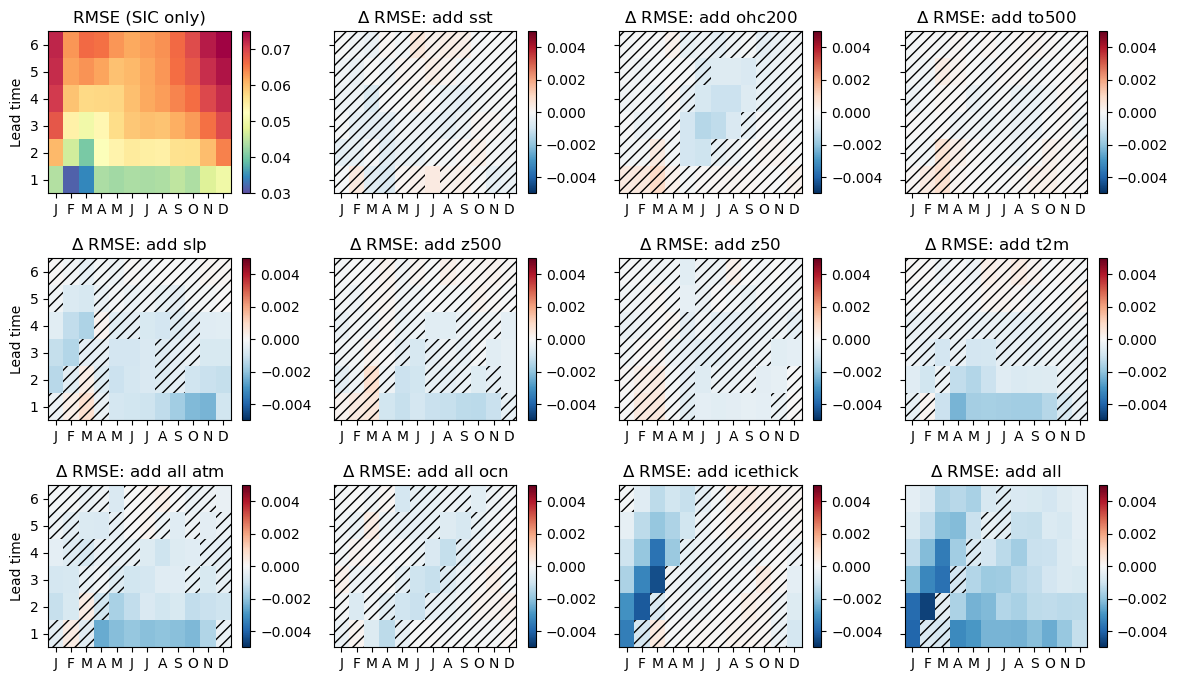

In [13]:
FALSE_DISCOVERY_RATE = 0.05
fig, axs = plt.subplots(nrows=3, ncols=4, figsize=(14, 8), sharey=True)

x = np.arange(13)
y = np.arange(7)
x_centers = (x[:-1] + x[1:]) / 2
y_centers = (y[:-1] + y[1:]) / 2

rmse_input2 = rmse_agg["input2"].mean("nn_member_id")
input_configs_to_plot = {
    "input3a": "sst", "input3f": "ohc200", "input3h_to500": "to500",
    "input3b": "slp", "input3c": "z500", "input3e": "z50", "input3d": "t2m",
    "input4a": "all atm", "input4b": "all ocn", "input3g": "icethick", "input5": "all",
}

axs = axs.flatten()
cax = axs[0].pcolormesh(x, y, rmse_input2, cmap="Spectral_r", shading="flat", vmin=0.03, vmax=0.075)
plot_markers(axs[0], rmse_input2 < persistence_rmse, x_centers, y_centers)
plot_markers(axs[0], rmse_input2 < climatology_rmse, x_centers, y_centers, "vk")
axs[0].set_yticks(y_centers, labels=np.arange(1, 7, 1))
axs[0].set_ylabel("Lead time")
axs[0].set_title("RMSE (SIC only)")
axs[0].set_xticks(x_centers, labels=["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
fig.colorbar(cax)

for i, input_config in enumerate(input_configs_to_plot):
    ax = axs[i+1]
    vrange = 0.005# if input_config in ["input4a", "input4b", "input3g", "input5"] else 0.0025
    cax = ax.pcolormesh(x, y, rmse_agg[input_config].mean("nn_member_id") - rmse_input2, cmap="RdBu_r", shading="flat", vmin=-vrange, vmax=vrange)
    significance_mask = (rmse_q_values.sel(config=input_config) > FALSE_DISCOVERY_RATE).astype(int)
    add_hatching(ax, significance_mask, x, y)
    ax.set_xticks(x_centers, labels=["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
    ax.set_yticks(y_centers, labels=np.arange(1, 7, 1))
    ax.set_title(f"$\Delta$ RMSE: add {input_configs_to_plot[input_config]}", fontsize=12)
    fig.colorbar(cax)

axs[4].set_ylabel("Lead time")
axs[8].set_ylabel("Lead time")
for i in range(len(axs)):
    if i - 1 >= len(input_configs_to_plot):
        axs[i].remove()

plt.subplots_adjust(hspace=0.4, wspace=0.25)
plt.savefig("figures/cesm_new/exp1_RMSE_absolute_extended.png", bbox_inches="tight", dpi=300)


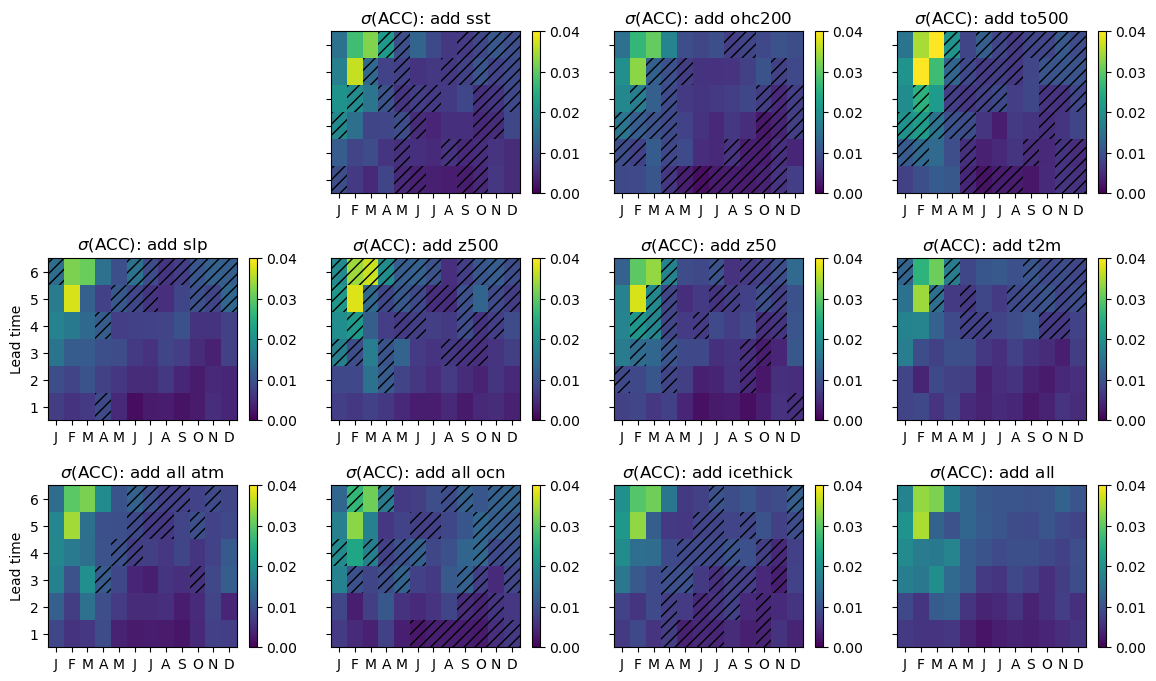

In [47]:
num_nn_members = 5
fig, axs = plt.subplots(nrows=3, ncols=4, figsize=(14, 8), sharey=True)
axs = axs.flatten()
acc_diffs_dict = {}

for i, input_config in enumerate(input_configs_to_plot.keys()):
    acc_diffs = np.zeros((6, 12, num_nn_members ** 2))
    for j in range(num_nn_members):
        for k in range(num_nn_members):
            acc_diffs[:,:,j*5 + k] = (acc_agg[input_config].isel(nn_member_id=j) - acc_agg["input2"].isel(nn_member_id=k)).values
    acc_diffs_dict[input_config] = acc_diffs

    ax = axs[i+1]
    cax = ax.pcolormesh(
        x, y, acc_diffs.std(axis=-1),
        cmap="viridis", shading="flat", vmin=0, vmax=0.04
    )
    significance_mask = (acc_q_values.sel(config=input_config) > P_VALUE_CUTOFF).astype(int)
    add_hatching(ax, significance_mask, x, y)
    ax.set_xticks(x_centers, labels=["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
    ax.set_yticks(y_centers, labels=np.arange(1, 7, 1))
    ax.set_title(fr"$\sigma$(ACC): add {input_configs_to_plot[input_config]}",
                fontsize = 12)
    fig.colorbar(cax)

axs[4].set_ylabel("Lead time")
axs[8].set_ylabel("Lead time")

axs[0].remove()
plt.subplots_adjust(hspace=0.4)
plt.savefig("figures/cesm_new/exp1_ACC_stdev_over_nn_members.png", bbox_inches="tight", dpi=300)


In [2]:
input3g_config = CONFIGS["input3g"]
input3g_data = util_cesm.load_inputs_data_da_dict(
    input3g_config.input_config, input3g_config.data_split
)
ice_occurrence_mask = xr.open_dataset(
    os.path.join(
        config_cesm.DATA_DIRECTORY,
        "cesm_data/grids/ice_occurrence_mask.nc",
    )
)["mask"].load()

predictions = {
    input_config: xr.open_dataset(
        os.path.join(
            config_cesm.PREDICTIONS_DIRECTORY,
            f"exp1_{input_config}",
            "UNetRes3_best_predictions.nc",
        ),
        chunks={
            "start_prediction_month": 12,
            "member_id": 1,
            "nn_member_id": -1,
            "lead_time": -1,
        },
    )["predictions"]
    for input_config in ["input2", "input3g"]
}


In [3]:
def lagged_correction_regression(
    predictions, added_config, baseline_config, predictor, initialization_month,
    lead_times=range(1, 7), lag_months=1, spatial_mask=None,
    anomalies=False, fill_value=None, raw_nonzero_predictor=None,
    minimum_nonzero_samples=500, fdr_alpha=0.05,
):
    """Regress added-minus-baseline ensemble-mean correction on a lagged field.

    predictor has time, member_id, y, x dimensions; lag is relative to forecast
    initialization (lag_months=1 selects April for May starts). Slopes describe
    correction per predictor unit. Optional anomalies subtract the pointwise
    mean across selected predictor years and members. BH pools space and leads.
    """
    if not 1 <= initialization_month <= 12 or lag_months < 0:
        raise ValueError("Use a month in 1..12 and a nonnegative lag.")
    def ensemble_mean(data):
        return data.mean("nn_member_id") if "nn_member_id" in data.dims else data

    added, baseline = xr.align(
        ensemble_mean(predictions[added_config]),
        ensemble_mean(predictions[baseline_config]), join="inner",
    )
    correction = (added - baseline).sel(lead_time=list(lead_times))
    correction = correction.where(
        correction.start_prediction_month.dt.month == initialization_month, drop=True
    )
    if correction.sizes["start_prediction_month"] == 0 or correction.sizes["member_id"] == 0:
        raise ValueError("No common forecasts for the requested month/configurations.")
    input_times = (
        pd.DatetimeIndex(correction.start_prediction_month.values)
        - pd.DateOffset(months=lag_months)
    )
    def select_predictor(field):
        return (
            field.sel(member_id=correction.member_id, time=input_times)
            .rename(time="start_prediction_month")
            .assign_coords(start_prediction_month=correction.start_prediction_month)
        )

    dims = ("start_prediction_month", "member_id")
    predictor_samples = select_predictor(predictor)
    if anomalies:
        predictor_samples = predictor_samples - predictor_samples.mean(dims)
    if fill_value is not None:
        predictor_samples = predictor_samples.fillna(fill_value)
    x, y = xr.align(predictor_samples, correction, join="exact")
    paired = np.isfinite(x) & np.isfinite(y)
    x, y = x.where(paired), y.where(paired)
    x_std, y_std = x.std(dims), y.std(dims)
    count = paired.sum(dims)
    valid = (count > 2) & (x_std > 0) & (y_std > 0)
    if spatial_mask is not None:
        valid = valid & spatial_mask
    if raw_nonzero_predictor is not None:
        nonzero_count = (select_predictor(raw_nonzero_predictor).fillna(0) > 0).sum(dims)
        valid = valid & (nonzero_count >= minimum_nonzero_samples)
    correlation = xr.corr(x, y, dim=dims).where(valid)
    # Reuse the correlation; no second regression fit is necessary.
    slope = correlation * y_std / x_std.where(x_std > 0)
    maps = xr.Dataset({
        "correlation": correlation,
        "slope": slope,
        "sample_count": count,
    }).compute()
    df = maps.sample_count - 2
    with np.errstate(divide="ignore", invalid="ignore"):
        t_statistic = np.abs(maps.correlation) * np.sqrt(
            df / (1 - maps.correlation.clip(min=-1, max=1) ** 2)
        )
    maps["p_value"] = 2 * xr.apply_ufunc(scipy.stats.t.sf, t_statistic, df)
    maps["q_value"] = maps.p_value.copy(
        data=benjamini_hochberg(maps.p_value.values)
    )
    maps["significant"] = maps.q_value <= fdr_alpha
    maps.attrs.update(
        added_config=added_config, baseline_config=baseline_config,
        initialization_month=initialization_month, lag_months=lag_months,
        predictor=predictor.name or "predictor", anomalies=int(anomalies),
        anomaly_reference="selected input years and members" if anomalies else "none",
        fdr_alpha=fdr_alpha, fdr_family="all finite spatial points and lead times",
    )
    maps.slope.attrs["description"] = "model correction per predictor unit"
    return maps


# Preserve the original January/December ice-thickness calculation.
with xr.open_dataset(
    os.path.join(config_cesm.DATA_DIRECTORY, "cesm_data/icethick/icethick_combined.nc"),
    chunks={"member_id": 1, "time": 12},
) as raw_icethick_ds:
    regression_maps = lagged_correction_regression(
        predictions, "input3g", "input2", input3g_data["icethick"],
        initialization_month=1, spatial_mask=(ice_occurrence_mask == 1),
        fill_value=0, raw_nonzero_predictor=raw_icethick_ds["icethick"],
    )


/home/groups/earlew/yuchen/miniconda3/envs/sicpred_env_conda/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


/home/groups/earlew/yuchen/miniconda3/envs/sicpred_env_conda/lib/python3.12/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/home/groups/earlew/yuchen/miniconda3/envs/sicpred_env_conda/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/groups/earlew/yuchen/miniconda3/envs/sicpred_env_conda/lib/python3.12/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/home/groups/earlew/yuchen/miniconda3/envs/sicpred_env_conda/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/groups/earlew/yuchen/miniconda3/envs/sicpred_env_conda/lib/python3.12/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered i

/tmp/ipykernel_8232/3945056475.py:51: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  plt.savefig("figures/cesm_new/exp1_icethick_sic_correction_regression.png", dpi=300, bbox_inches='tight')
/tmp/ipykernel_8232/3945056475.py:51: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  plt.savefig("figures/cesm_new/exp1_icethick_sic_correction_regression.png", dpi=300, bbox_inches='tight')
/home/users/yucli/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


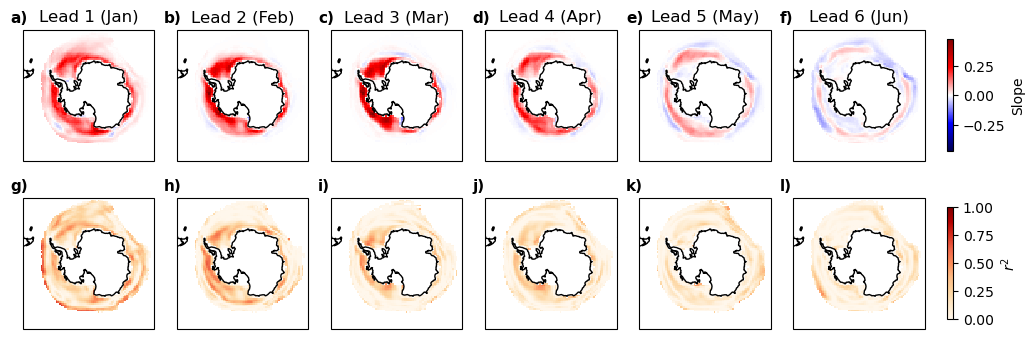

In [18]:
def plot_lagged_regression_maps(regression_maps, figsize=(12, 4)):
    """Plot slopes above squared correlations with one right-side colorbar per row."""
    fig = plt.figure(figsize=figsize, constrained_layout=True)
    lead_times = regression_maps.lead_time.values
    grid = fig.add_gridspec(2, len(lead_times) + 1, width_ratios=[1] * len(lead_times) + [0.045])
    slope_limit = float(np.abs(regression_maps.slope).max(skipna=True))
    if not np.isfinite(slope_limit) or slope_limit == 0:
        slope_limit = 1.0

    axs = []

    initialization_month = int(regression_maps.attrs["initialization_month"])
    for row, (field, label, cmap, vmin, vmax) in enumerate([
        (regression_maps.slope, "Slope", "seismic", -slope_limit, slope_limit),
        (regression_maps.correlation ** 2, r"$r^2$", "OrRd", 0, 1),
    ]):
        for column, lead_time in enumerate(lead_times):
            ax = fig.add_subplot(grid[row, column], projection=ccrs.SouthPolarStereo())
            axs.append(ax)
            im = ax.pcolormesh(
                reference_grid.lon, reference_grid.lat,
                field.sel(lead_time=lead_time),
                transform=ccrs.PlateCarree(), cmap=cmap, vmin=vmin, vmax=vmax,
            )
            # ax.contourf(
            #     reference_grid.lon, reference_grid.lat,
            #     regression_maps.significant.sel(lead_time=lead_time),
            #     levels=[0.5, 1.5], hatches=["..."], colors="none",
            #     transform=ccrs.PlateCarree(),
            # )
            ax.coastlines()
            ax.set_extent([-180, 180, -90, -52.5], crs=ccrs.PlateCarree())
            ax.set_box_aspect(1)
            if row == 0:
                # Lead 1 is the initialization month (January lead 3 is March).
                prediction_month = (initialization_month + int(lead_time) - 2) % 12 + 1
                month_label = pd.Timestamp(2000, prediction_month, 1).strftime("%b")
                ax.set_title(f"Lead {lead_time} ({month_label})")
        # Center each colorbar in its reserved column at 80% of the row height.
        colorbar_grid = grid[row, -1].subgridspec(
            3, 1, height_ratios=[1, 8, 1], hspace=0
        )
        colorbar_ax = fig.add_subplot(colorbar_grid[1, 0])
        fig.colorbar(im, cax=colorbar_ax, label=label)

    add_subplot_labels(axs)
    return fig


fig = plot_lagged_regression_maps(regression_maps)
plt.savefig("figures/cesm_new/exp1_icethick_sic_correction_regression.png", dpi=300, bbox_inches='tight')

In [8]:
# April anomalies for May-start corrections; raw fields retain physical units.
# input3f adds ohc200 (upper-200-m heat content).
for input_config in ["input3a", "input3f"]:
    if input_config not in predictions:
        predictions[input_config] = xr.open_dataset(
            os.path.join(
                config_cesm.PREDICTIONS_DIRECTORY, f"exp1_{input_config}",
                "UNetRes3_best_predictions.nc",
            ),
            chunks={"start_prediction_month": 12, "member_id": 1,
                    "nn_member_id": -1, "lead_time": -1},
        )["predictions"]

ocean_regression_maps = {}
for added_config, variable in [("input3a", "sst"), ("input3f", "ohc200")]:
    with xr.open_dataset(
        os.path.join(config_cesm.DATA_DIRECTORY, f"cesm_data/{variable}/{variable}_combined.nc"),
        chunks={"member_id": 1, "time": 12},
    ) as predictor_ds:
        ocean_regression_maps[variable] = lagged_correction_regression(
            predictions, added_config, "input2", predictor_ds[variable],
            initialization_month=5, lag_months=6, anomalies=True,
            spatial_mask=(ice_occurrence_mask == 1),
        )


In [ ]:
# May-start SST correction versus April SST anomalies.
fig_sst = plot_lagged_regression_maps(ocean_regression_maps["sst"])
fig_sst.savefig("figures/cesm_new/exp1_sst_sic_correction_regression.png", dpi=300, bbox_inches="tight")


In [ ]:
# May-start OHC200 correction versus April OHC200 anomalies.
fig_ohc200 = plot_lagged_regression_maps(ocean_regression_maps["ohc200"])
fig_ohc200.savefig("figures/cesm_new/exp1_ohc200_sic_correction_regression.png", dpi=300, bbox_inches="tight")


In [142]:
acc_diff_icethick = acc["input3g"] - acc["input2"]
rmse_diff_icethick = rmse["input2"] - rmse["input3g"] # higher means input3g is better


def metric_exceedance_mask(
    metric_diff, initialization_month, lead_time, diff_threshold
):
    """Select forecasts whose NN-mean metric gain exceeds a threshold."""
    metric_at_target = metric_diff.sel(lead_time=lead_time).where(
        metric_diff.start_prediction_month.dt.month == initialization_month,
        drop=True,
    )
    return (metric_at_target.mean("nn_member_id") > diff_threshold).compute()


# The completed diagnostics have a maximum ensemble-mean gain of about 0.296,
# so 0.25 provides a small test subset (seven cases). Change as desired.
INITIALIZATION_MONTH = 12
LEAD_TIME = 3
ACC_DIFF_THRESHOLD = 0.25
RMSE_DIFF_THRESHOLD = 0.015

metric = "rmse"

if metric == "rmse":
    icethick_subset_mask = metric_exceedance_mask(
        rmse_diff_icethick,
        initialization_month=INITIALIZATION_MONTH,
        lead_time=LEAD_TIME,
        diff_threshold=RMSE_DIFF_THRESHOLD,
    )
elif metric == "acc":
    icethick_subset_mask = metric_exceedance_mask(
        acc_diff_icethick,
        initialization_month=INITIALIZATION_MONTH,
        lead_time=LEAD_TIME,
        diff_threshold=ACC_DIFF_THRESHOLD,
    )

valid_subset_samples = (
    icethick_subset_mask
    .stack(sample=("start_prediction_month", "member_id"))
    .where(lambda values: values, drop=True)
    .sample.to_index()
)

print(f"{len(valid_subset_samples)} forecasts in the subset")
valid_subset_samples


2 forecasts in the subset


MultiIndex([('1925-12-01', 'r3i1041p1f1'),
            ('1966-12-01', 'r2i1281p1f1')],
           names=['start_prediction_month', 'member_id'])

In [147]:
# Pick any pair listed in valid_subset_samples above.
member_id = "r2i1281p1f1"
start_prediction_month = pd.Timestamp("1966-12-01")


In [124]:
def select_example_sequences(member_id, start_prediction_month):
    """Load the six input and forecast sequences for one selected case."""
    start_prediction_month = pd.Timestamp(start_prediction_month)
    sample = (start_prediction_month, member_id)
    if sample not in valid_subset_samples:
        raise ValueError(
            f"{sample} is not in valid_subset_samples. Choose a pair printed "
            "by the preceding subset cell."
        )

    input_months = pd.date_range(
        start_prediction_month - pd.DateOffset(months=6),
        periods=6,
        freq="MS",
    )
    forecast_months = pd.date_range(
        start_prediction_month, periods=6, freq="MS"
    )

    sequences = {
        "SIC input": input3g_data["icefrac"].sel(
            member_id=member_id, time=input_months
        ).rename(time="sequence_month"),
        "Ice thickness input": input3g_data["icethick"].sel(
            member_id=member_id, time=input_months
        ).rename(time="sequence_month"),
        "SIC prediction: input2": predictions["input2"].sel(
            member_id=member_id,
            start_prediction_month=start_prediction_month,
        ).mean("nn_member_id").rename(lead_time="sequence_month"),
        "SIC prediction: input3g": predictions["input3g"].sel(
            member_id=member_id,
            start_prediction_month=start_prediction_month,
        ).mean("nn_member_id").rename(lead_time="sequence_month"),
        "SIC truth": input3g_data["icefrac"].sel(
            member_id=member_id, time=forecast_months
        ).rename(time="sequence_month"),
        "Ice thickness truth": input3g_data["icethick"].sel(
            member_id=member_id, time=forecast_months
        ).rename(time="sequence_month"),
    }

    for name, sequence in sequences.items():
        valid_times = input_months if name.endswith("input") else forecast_months
        sequences[name] = sequence.assign_coords(
            sequence_month=np.arange(6),
            valid_time=("sequence_month", valid_times),
        ).where(ice_occurrence_mask == 1).load()

    return sequences


def plot_example_sequences(sequences, member_id, start_prediction_month):
    """Plot model-space SIC and thickness inputs, forecasts, and truth."""
    row_names = list(sequences)
    sic_rows = [name for name in row_names if name.startswith("SIC")]
    thickness_rows = [name for name in row_names if "thickness" in name]

    sic_limit = max(
        float(np.nanquantile(np.abs(sequences[name]), 0.99))
        for name in sic_rows
    )
    thickness_limit = max(
        float(np.nanquantile(np.abs(sequences[name]), 0.99))
        for name in thickness_rows
    )
    plot_settings = {
        **{
            name: {"cmap": "RdBu_r", "vmin": -sic_limit, "vmax": sic_limit}
            for name in sic_rows
        },
        **{
            name: {
                "cmap": "RdBu_r",
                "vmin": -thickness_limit,
                "vmax": thickness_limit,
            }
            for name in thickness_rows
        },
    }

    lon = reference_grid.lon.data
    lat = reference_grid.lat.data
    fig, axs = plt.subplots(
        nrows=len(row_names),
        ncols=6,
        figsize=(15, 13),
        subplot_kw={"projection": ccrs.SouthPolarStereo()},
    )

    row_images = {}
    for row, name in enumerate(row_names):
        sequence = sequences[name]
        for col in range(6):
            ax = axs[row, col]
            row_images[name] = ax.pcolormesh(
                lon,
                lat,
                sequence.isel(sequence_month=col),
                transform=ccrs.PlateCarree(),
                shading="auto",
                **plot_settings[name],
            )
            ax.coastlines(linewidth=0.4)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title(
                pd.Timestamp(sequence.valid_time.values[col]).strftime("%b %Y"),
                fontsize=9,
            )
            if col == 0:
                ax.text(
                    -0.12,
                    0.5,
                    name,
                    transform=ax.transAxes,
                    ha="right",
                    va="center",
                    rotation=90,
                    fontsize=9,
                )

    for row, name in enumerate(row_names):
        label = (
            "Detrended SIC anomaly"
            if name.startswith("SIC")
            else "Normalized, detrended ice thickness"
        )
        fig.colorbar(
            row_images[name],
            ax=axs[row, :],
            orientation="vertical",
            fraction=0.012,
            pad=0.01,
            label=label,
        )

    start_prediction_month = pd.Timestamp(start_prediction_month)
    selected_gain = float(
        acc_diff_icethick.sel(
            member_id=member_id,
            start_prediction_month=start_prediction_month,
            lead_time=LEAD_TIME,
        ).mean("nn_member_id")
    )
    fig.suptitle(
        f"{member_id}; initialized {start_prediction_month:%b %Y}; "
        f"lead-{LEAD_TIME} ACC gain = {selected_gain:.3f}\n"
        "Predictions are means over the five neural-network members",
        y=1.01,
    )
    return fig, axs


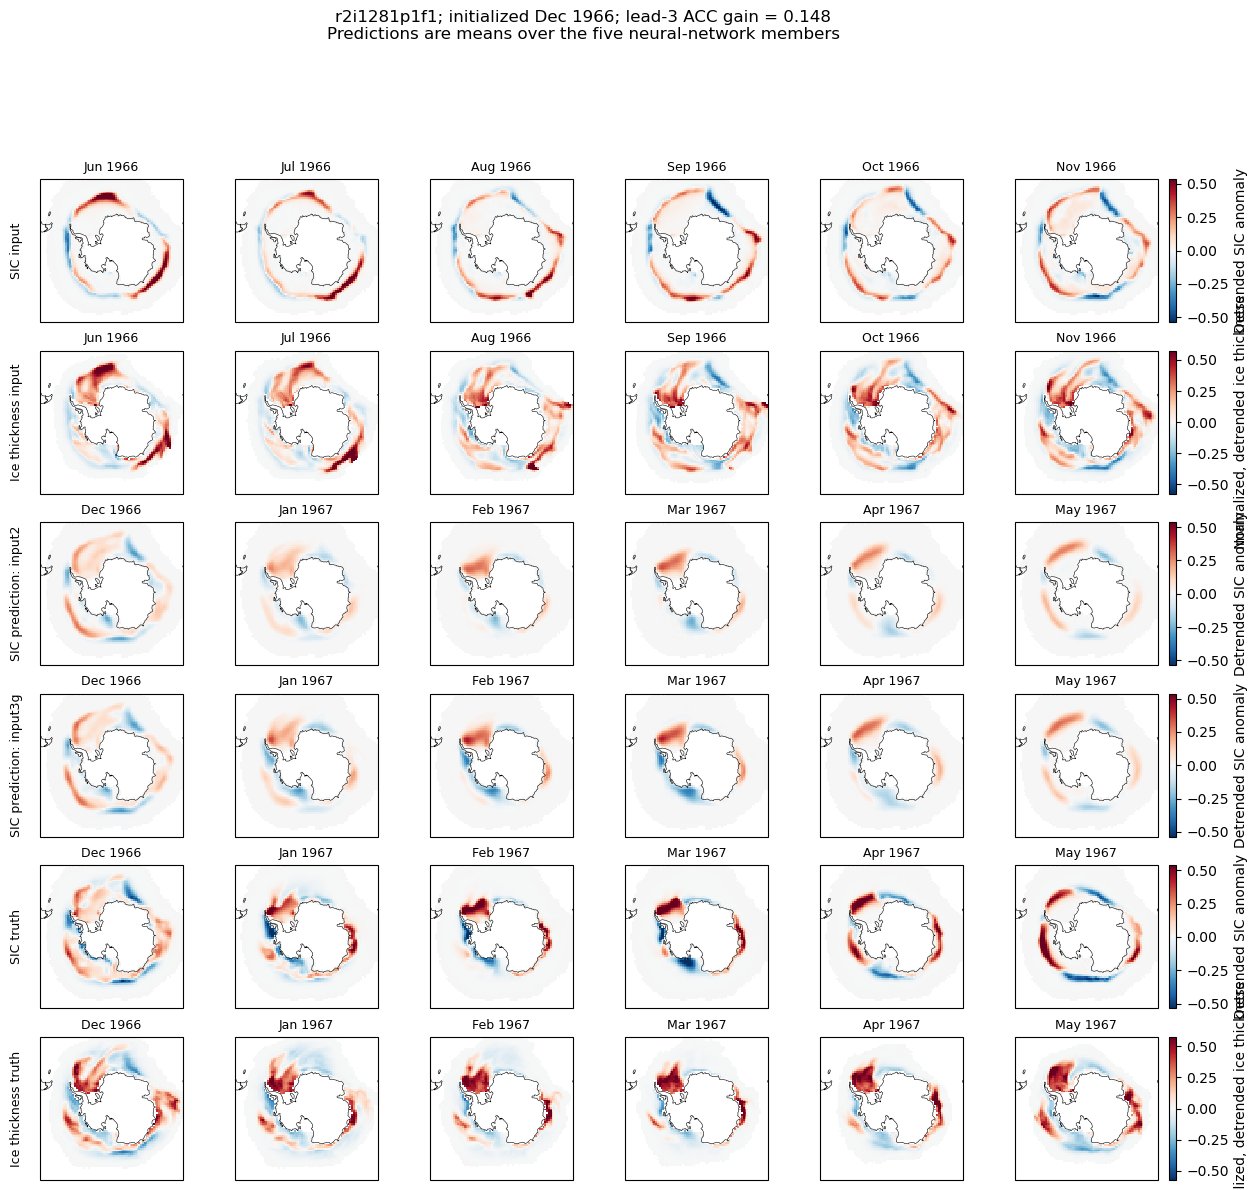

In [148]:
example_sequences = select_example_sequences(
    member_id, start_prediction_month
)
fig, axs = plot_example_sequences(
    example_sequences, member_id, start_prediction_month
)


Example plot of normalized inputs

In [144]:

input5_config = CONFIGS["input5"]
input5_data = util_cesm.load_inputs_data_da_dict(
    input5_config.input_config, input5_config.data_split
)

test_member = input5_config.data_split["test"][0]
init_month = pd.Timestamp("2000-01-01")
input_months = pd.date_range(
    init_month - pd.DateOffset(months=12), periods=12, freq="MS"
)
physical_inputs = [
    name for name, settings in input5_config.input_config.items()
    if settings["include"] and not settings["auxiliary"]
]

lon = reference_grid.lon.data
lat = reference_grid.lat.data
fig, axs = plt.subplots(
    nrows=len(physical_inputs), ncols=len(input_months), figsize=(18, 13),
    sharex=True, sharey=True,
    subplot_kw={"projection": ccrs.SouthPolarStereo()},
)

for row, name in enumerate(physical_inputs):
    sample = input5_data[name].sel(
        member_id=test_member, time=input_months
    ).squeeze()
    vlim = float(np.nanquantile(np.abs(sample.values), 0.99))
    vlim = max(vlim, np.finfo(float).eps)

    for col, month in enumerate(input_months):
        ax = axs[row, col]
        im = ax.pcolormesh(
            lon, lat, sample.sel(time=month), transform=ccrs.PlateCarree(),
            cmap="seismic_r", vmin=-vlim, vmax=vlim,
        )
        ax.coastlines(linewidth=0.5)
        ax.set_xticks([])
        ax.set_yticks([])

        if row == 0:
            ax.set_title(month.strftime("%b %Y"), fontsize=9)
        if col == 0:
            ax.text(-0.12, 0.5, name, transform=ax.transAxes,
                    ha="right", va="center", rotation=90, fontsize=8)
fig.suptitle(
    f"Normalized variables ({test_member}, start_pred_month {init_month:%b %Y})", fontsize=14, y=0.95
)
plt.savefig("figures/illustrations/example_normalized_inputs.png", dpi=150, bbox_inches='tight')
for data_array in input5_data.values():
    data_array.close()


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7f8d03623b00> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 